<a href="https://colab.research.google.com/github/Suvetha-14/Student-Performance-Analytics-Dashboard/blob/main/Student__performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Student Performance Analytics Dashboard
!pip install pandas numpy matplotlib seaborn scikit-learn

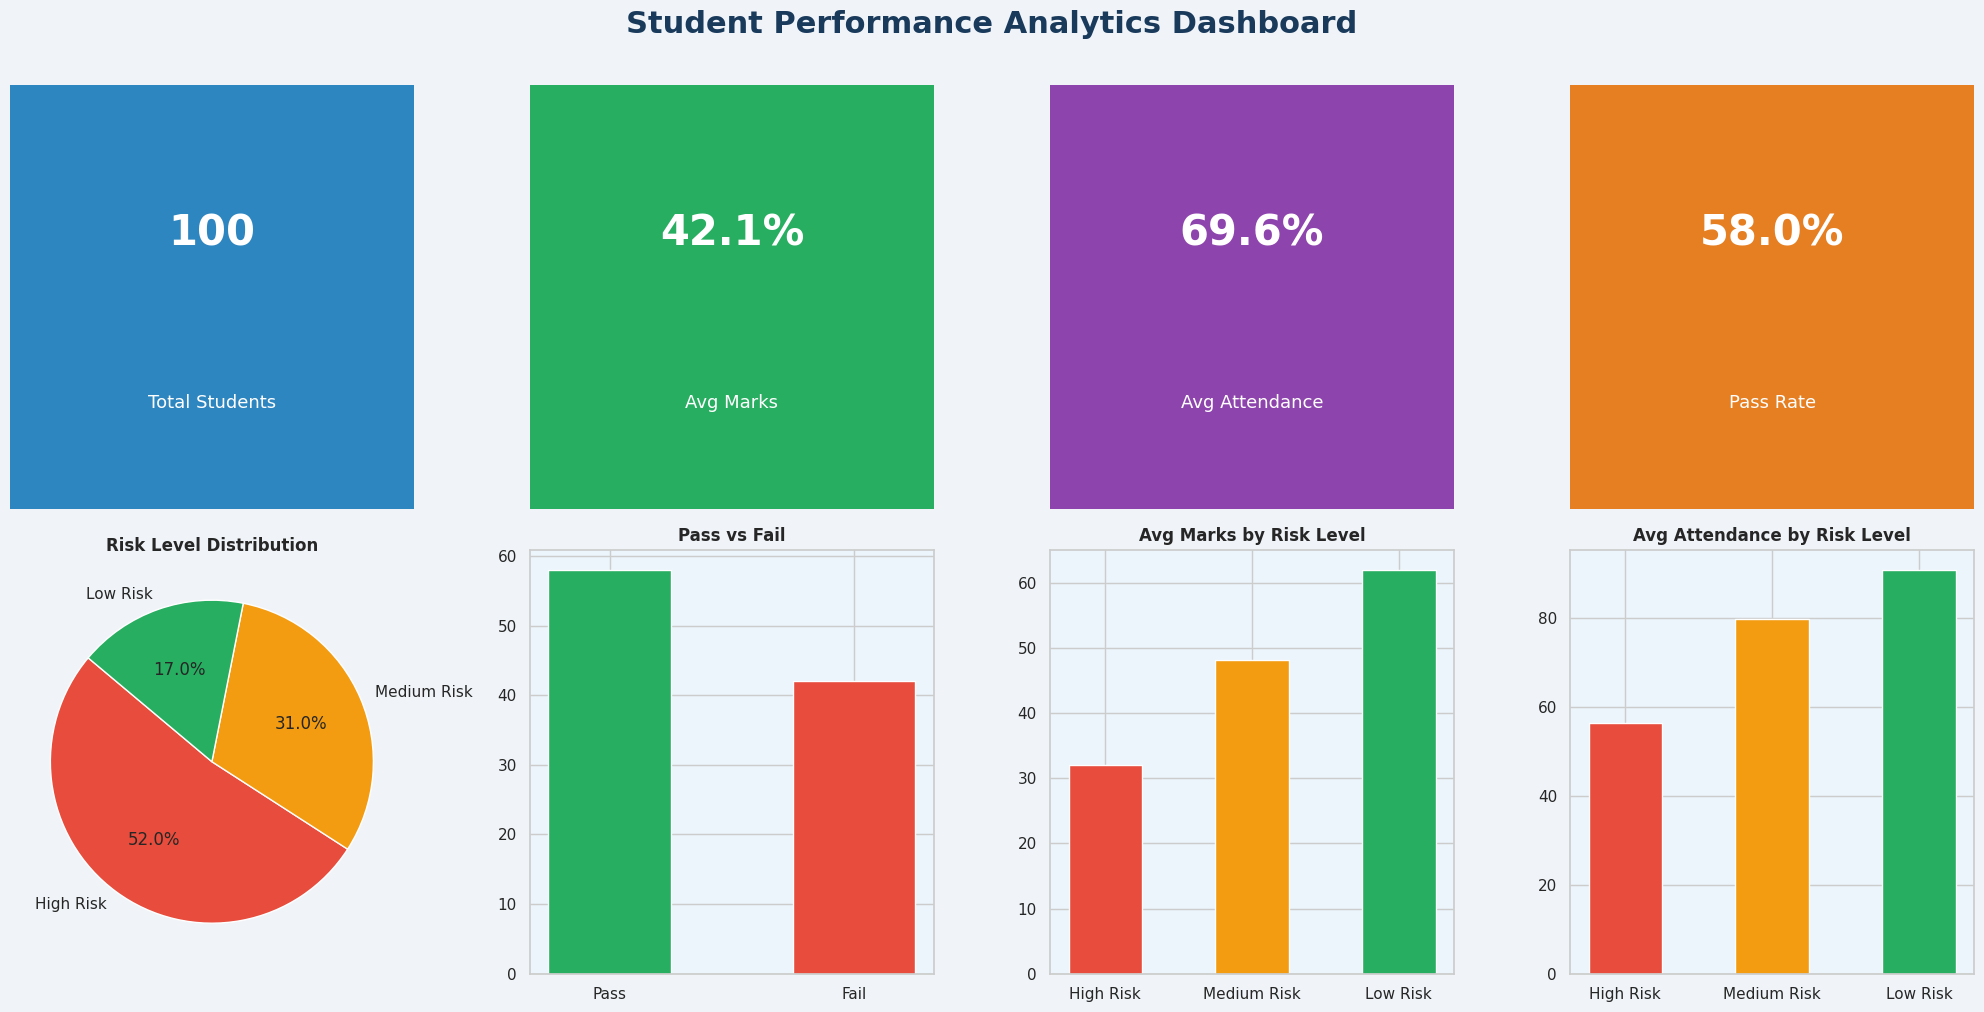

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
COLORS = {"High Risk": "#E74C3C", "Medium Risk": "#F39C12", "Low Risk": "#27AE60"}
LIGHT = "#EBF5FB"

df = pd.read_csv("student_data_clean.csv")

# ── PAGE 1 — OVERVIEW ──
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.patch.set_facecolor("#F0F4F8")
fig.suptitle("Student Performance Analytics Dashboard", fontsize=22, fontweight='bold', color="#1A3A5C", y=1.01)

kpis = [
    ("Total Students", len(df), "#2E86C1"),
    ("Avg Marks", f"{df['Average_Marks'].mean():.1f}%", "#27AE60"),
    ("Avg Attendance", f"{df['Attendance_%'].mean():.1f}%", "#8E44AD"),
    ("Pass Rate", f"{(df['Status']=='Pass').mean()*100:.1f}%", "#E67E22"),
]
for ax, (title, val, color) in zip(axes[0], kpis):
    ax.set_facecolor(color)
    ax.text(0.5, 0.65, str(val), ha='center', va='center', fontsize=30, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.25, title, ha='center', va='center', fontsize=13, color='white', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)

risk_counts = df['Risk_Level'].value_counts()
axes[1][0].pie(risk_counts, labels=risk_counts.index, colors=[COLORS[r] for r in risk_counts.index], autopct='%1.1f%%', startangle=140)
axes[1][0].set_title("Risk Level Distribution", fontweight='bold')

status_counts = df['Status'].value_counts()
axes[1][1].bar(status_counts.index, status_counts.values, color=["#27AE60","#E74C3C"], width=0.5)
axes[1][1].set_title("Pass vs Fail", fontweight='bold')
axes[1][1].set_facecolor(LIGHT)

avg_by_risk = df.groupby('Risk_Level')['Average_Marks'].mean().reindex(["High Risk","Medium Risk","Low Risk"])
axes[1][2].bar(avg_by_risk.index, avg_by_risk.values, color=[COLORS[r] for r in avg_by_risk.index], width=0.5)
axes[1][2].set_title("Avg Marks by Risk Level", fontweight='bold')
axes[1][2].set_facecolor(LIGHT)

att_by_risk = df.groupby('Risk_Level')['Attendance_%'].mean().reindex(["High Risk","Medium Risk","Low Risk"])
axes[1][3].bar(att_by_risk.index, att_by_risk.values, color=[COLORS[r] for r in att_by_risk.index], width=0.5)
axes[1][3].set_title("Avg Attendance by Risk Level", fontweight='bold')
axes[1][3].set_facecolor(LIGHT)

plt.tight_layout()
plt.savefig("page1_overview.png", dpi=150, bbox_inches='tight')
plt.show()


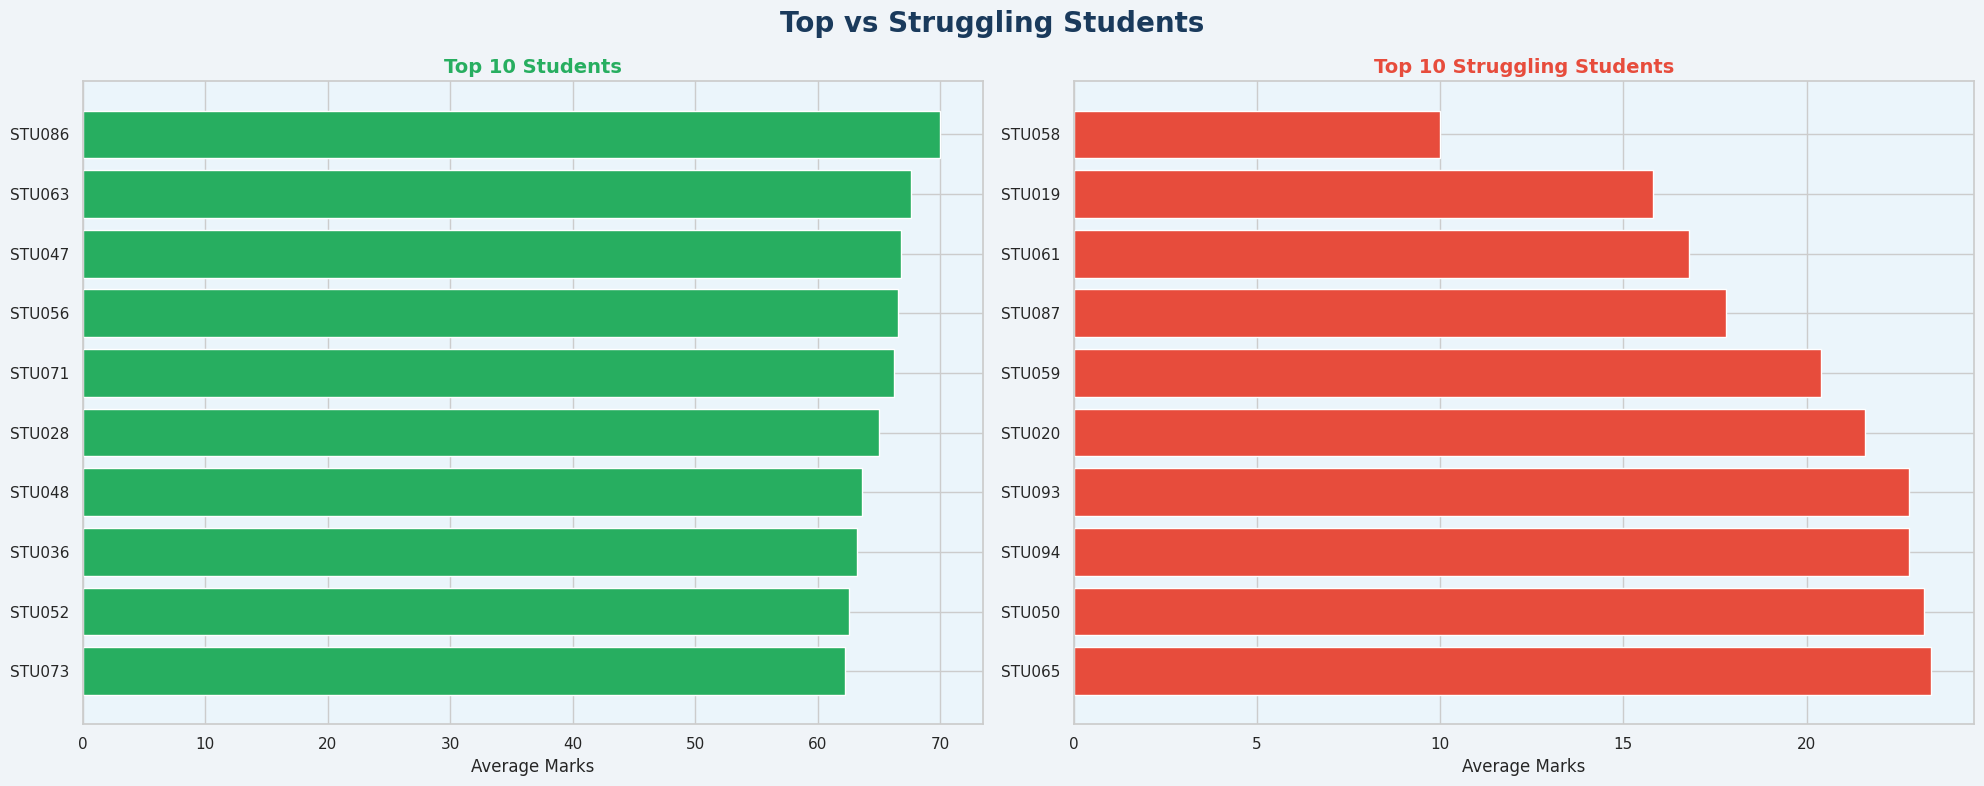

In [ ]:
# ── PAGE 2 — TOP VS STRUGGLING STUDENTS ──
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor("#F0F4F8")
fig.suptitle("Top vs Struggling Students", fontsize=20, fontweight='bold', color="#1A3A5C")

top10 = df.nlargest(10, 'Average_Marks')
struggling10 = df.nsmallest(10, 'Average_Marks')

# Top 10
axes[0].barh(top10['Student_ID'], top10['Average_Marks'], color="#27AE60", edgecolor='white')
axes[0].set_title("Top 10 Students", fontweight='bold', color="#27AE60", fontsize=14)
axes[0].set_xlabel("Average Marks")
axes[0].set_facecolor(LIGHT)
axes[0].invert_yaxis()

# Struggling 10
axes[1].barh(struggling10['Student_ID'], struggling10['Average_Marks'], color="#E74C3C", edgecolor='white')
axes[1].set_title("Top 10 Struggling Students", fontweight='bold', color="#E74C3C", fontsize=14)
axes[1].set_xlabel("Average Marks")
axes[1].set_facecolor(LIGHT)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("page2_top_vs_struggling.png", dpi=150, bbox_inches='tight')
plt.show()


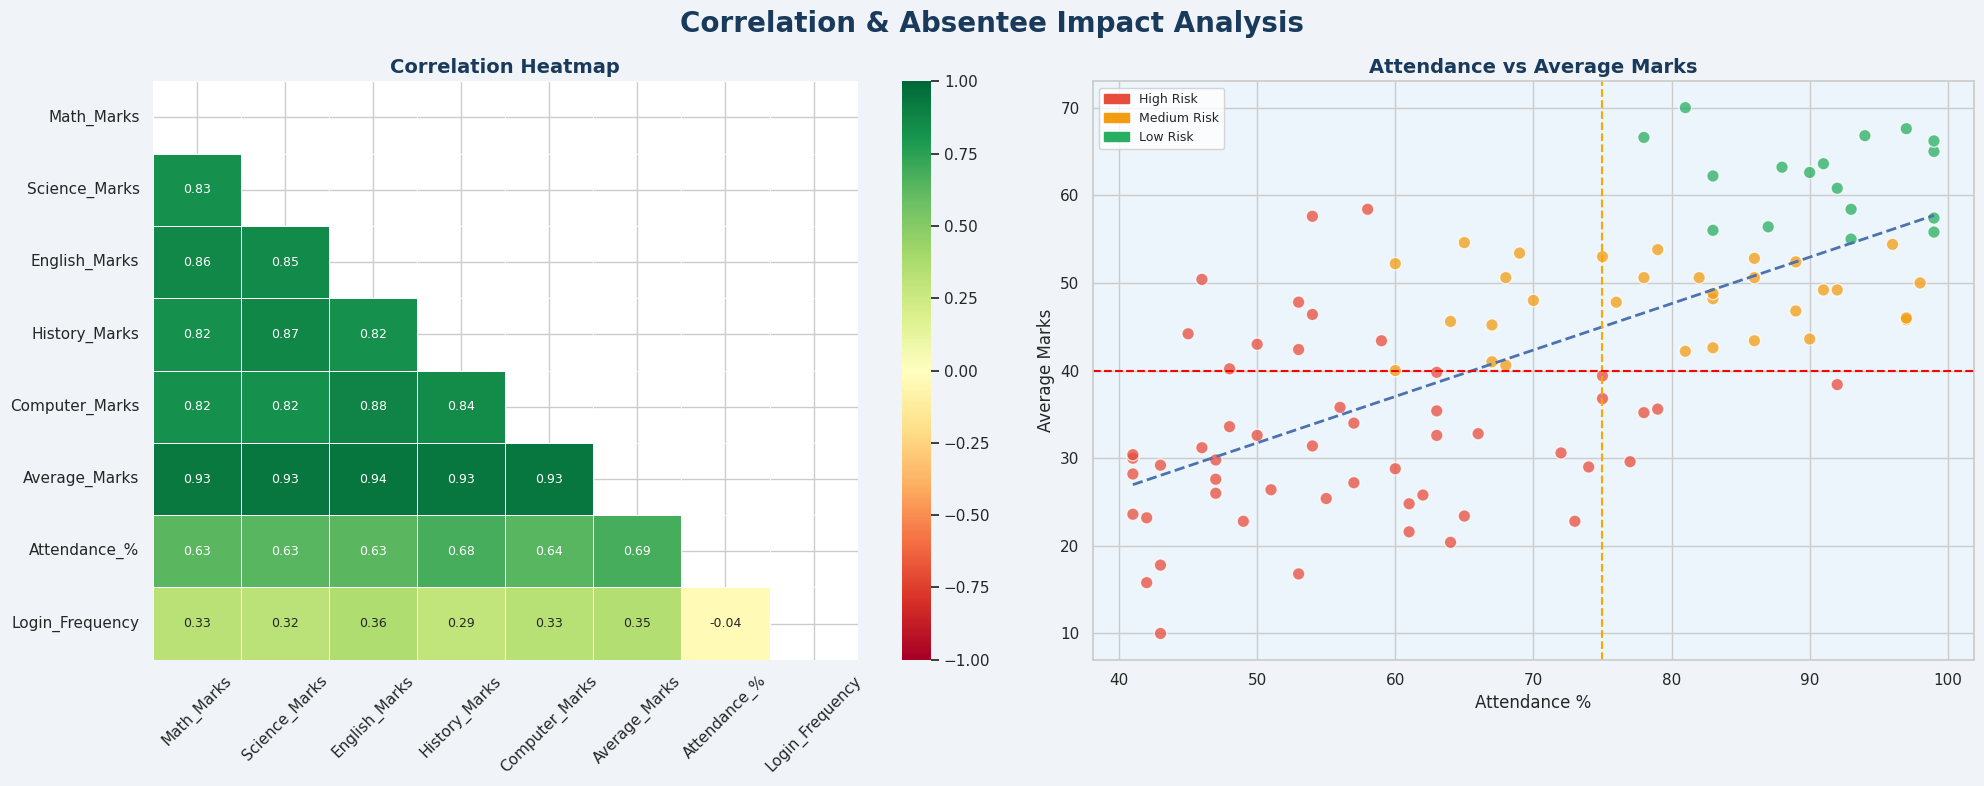

In [ ]:
# ── PAGE 3 — CORRELATION HEATMAP ──
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor("#F0F4F8")
fig.suptitle("Correlation & Absentee Impact Analysis", fontsize=20, fontweight='bold', color="#1A3A5C")

# Heatmap
corr_cols = ['Math_Marks','Science_Marks','English_Marks',
             'History_Marks','Computer_Marks','Average_Marks',
             'Attendance_%','Login_Frequency']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            mask=mask, ax=axes[0], linewidths=0.5,
            annot_kws={"size": 9}, vmin=-1, vmax=1)
axes[0].set_title("Correlation Heatmap", fontweight='bold', color="#1A3A5C", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# Scatter
risk_color_map = df['Risk_Level'].map(COLORS)
axes[1].scatter(df['Attendance_%'], df['Average_Marks'],
                c=risk_color_map, s=80, alpha=0.75, edgecolors='white')
z = np.polyfit(df['Attendance_%'], df['Average_Marks'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Attendance_%'].min(), df['Attendance_%'].max(), 100)
axes[1].plot(x_line, p(x_line), "b--", linewidth=2, label="Trend Line")
axes[1].axvline(x=75, color='orange', linestyle='--', linewidth=1.5, label="75% Attendance")
axes[1].axhline(y=40, color='red', linestyle='--', linewidth=1.5, label="Pass Mark (40)")
axes[1].set_xlabel("Attendance %", fontsize=12)
axes[1].set_ylabel("Average Marks", fontsize=12)
axes[1].set_title("Attendance vs Average Marks", fontweight='bold', color="#1A3A5C", fontsize=14)
axes[1].set_facecolor(LIGHT)
patches = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
axes[1].legend(handles=patches, fontsize=9)

plt.tight_layout()
plt.savefig("page3_correlation.png", dpi=150, bbox_inches='tight')
plt.show()


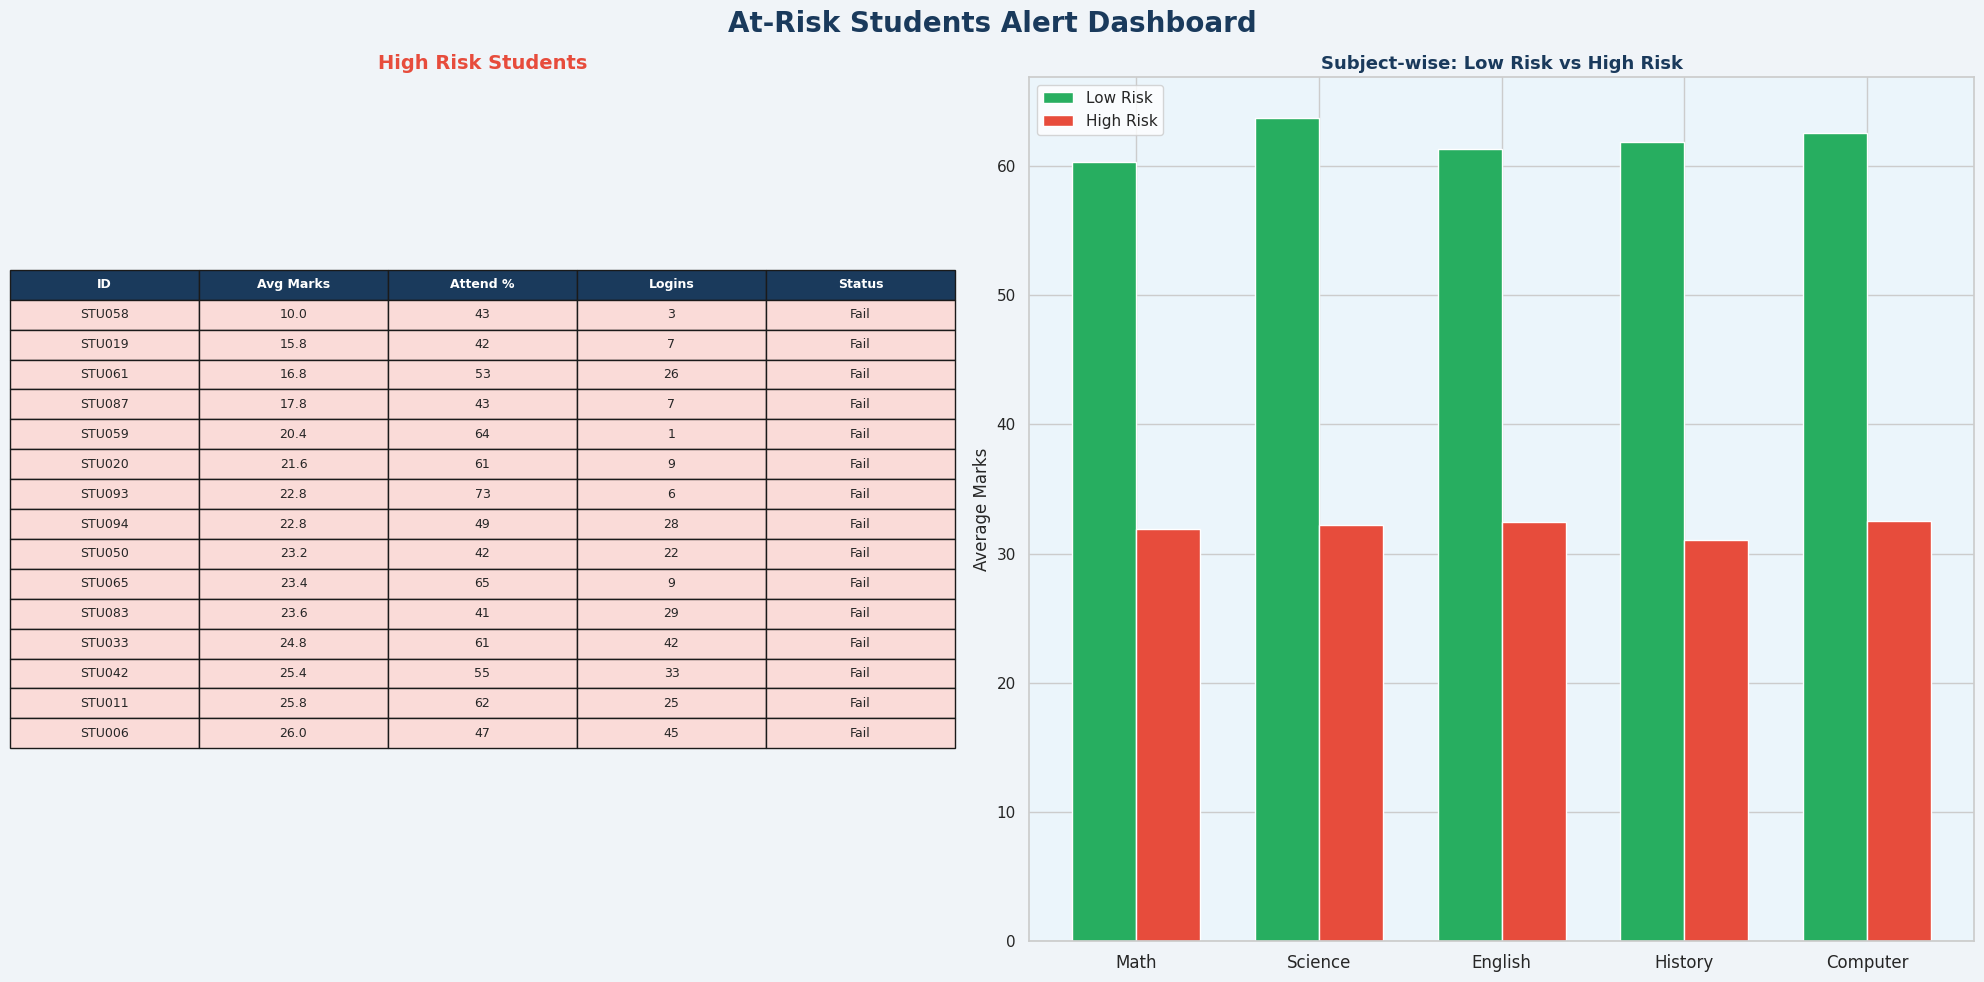

In [ ]:
# ── PAGE 4 — AT-RISK STUDENTS ALERT ──
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.patch.set_facecolor("#F0F4F8")
fig.suptitle("At-Risk Students Alert Dashboard", fontsize=20, fontweight='bold', color="#1A3A5C")

# Table
high_risk = df[df['Risk_Level'] == 'High Risk'].sort_values('Average_Marks')[
    ['Student_ID','Average_Marks','Attendance_%','Login_Frequency','Status']].head(15)

axes[0].axis('off')
table = axes[0].table(
    cellText=high_risk.values.tolist(),
    colLabels=['ID','Avg Marks','Attend %','Logins','Status'],
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

for j in range(5):
    table[0, j].set_facecolor("#1A3A5C")
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(high_risk)+1):
    color = "#FADBD8" if high_risk.iloc[i-1]['Status'] == "Fail" else "#FDEBD0"
    for j in range(5):
        table[i, j].set_facecolor(color)

axes[0].set_title("High Risk Students", fontweight='bold', color="#E74C3C", fontsize=14)

# Subject wise bar chart
subjects = ['Math_Marks','Science_Marks','English_Marks','History_Marks','Computer_Marks']
labels = ['Math','Science','English','History','Computer']

low_avg  = df[df['Risk_Level'] == 'Low Risk'][subjects].mean()
high_avg = df[df['Risk_Level'] == 'High Risk'][subjects].mean()

x = np.arange(len(labels))
w = 0.35
axes[1].bar(x - w/2, low_avg,  w, label='Low Risk',  color="#27AE60", edgecolor='white')
axes[1].bar(x + w/2, high_avg, w, label='High Risk',  color="#E74C3C", edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=12)
axes[1].set_ylabel("Average Marks")
axes[1].set_title("Subject-wise: Low Risk vs High Risk", fontweight='bold', color="#1A3A5C", fontsize=13)
axes[1].legend(fontsize=11)
axes[1].set_facecolor(LIGHT)

plt.tight_layout()
plt.savefig("page4_atrisk.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files

files.download("student_data_clean.csv")
files.download("page1_overview.png")
files.download("page2_top_vs_struggling.png")
files.download("page3_correlation.png")
files.download("page4_atrisk.png")

print("✅ All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!
